Question3: Consider the function $f(t) = e−t2/2$ over the interval [0,2].

(a) Use scipy’s CubicSpline function to determine the clamped cubic spline S(t) that interpolates
f(t) at the points where 
        t= 0.0,0.25,0.5,1.25,2.0.

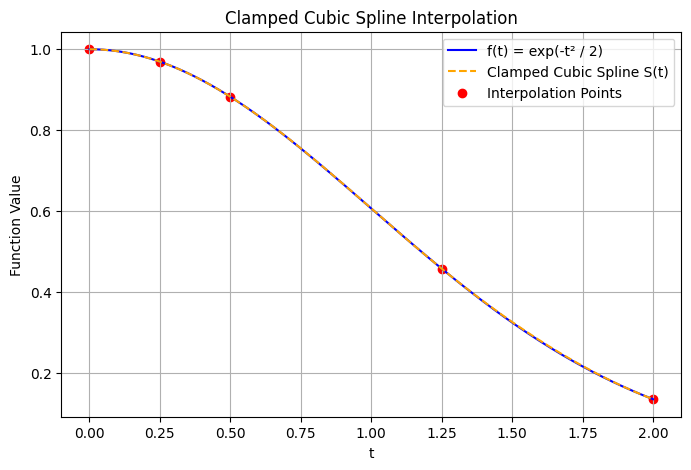

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 定义目标函数 f(t) 和导数 f'(t)
def f(t): return np.exp(-0.5 * t**2)

def f_prime(t): return -t * np.exp(-0.5 * t**2)

# 插值节点
t_data = np.array([0.0, 0.25, 0.5, 1.25, 2.0])
f_data = f(t_data)

# Clamped 边界条件：一阶导数匹配
bc_type = ((1, f_prime(0.0)), (1, f_prime(2.0)))

# 构造 clamped cubic spline 插值函数
S = CubicSpline(t_data, f_data, bc_type=bc_type)

# 生成用于绘图的细分点
t_dense = np.linspace(0, 2, 500)
f_dense = f(t_dense)
S_dense = S(t_dense)

# 绘图：原函数与样条插值对比
plt.figure(figsize=(8, 5))
plt.plot(t_dense, f_dense, label='f(t) = exp(-t² / 2)', color='blue')
plt.plot(t_dense, S_dense, label='Clamped Cubic Spline S(t)', linestyle='--', color='orange')
plt.scatter(t_data, f_data, color='red', label='Interpolation Points')
plt.title('Clamped Cubic Spline Interpolation')
plt.xlabel('t')
plt.ylabel('Function Value')
plt.legend()
plt.grid(True)
plt.show()

(b) Estimate the accuracy of S(t) by determining the maximum error at 501 equally spaced points
in [0,2]. That is, compute the value of

        Emax = max 1≤i≤501 |f(ti)−S(ti)|.

How does the bound compare with the bound given in the class?
The documentation for scipy’s CubicSpline may be a little confusing. Use bc type = ((1,
f’(0.0)), (1, f’(2.0))), where f’(0.0) and f’(2.0) are the appropriate derivative values.

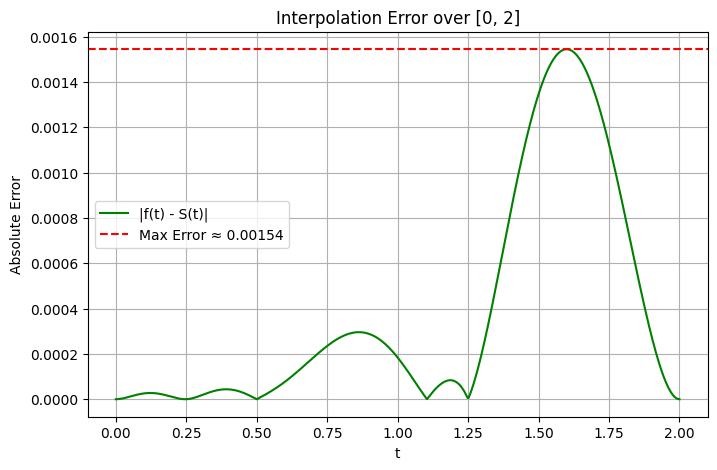

E_max ≈ 0.00154488


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 定义函数及导数
def f(t):
    return np.exp(-0.5 * t**2)

def f_prime(t):
    return -t * np.exp(-0.5 * t**2)

# 插值节点与数据
t_data = np.array([0.0, 0.25, 0.5, 1.25, 2.0])
f_data = f(t_data)
bc_type = ((1, f_prime(0.0)), (1, f_prime(2.0)))
S = CubicSpline(t_data, f_data, bc_type=bc_type)

# 501 个点上计算误差
t_eval = np.linspace(0, 2, 501)
f_eval = f(t_eval)
S_eval = S(t_eval)
error = np.abs(f_eval - S_eval)
E_max = np.max(error)

# 误差展示
plt.figure(figsize=(8, 5))
plt.plot(t_eval, error, label='|f(t) - S(t)|', color='green')
plt.axhline(E_max, color='red', linestyle='--', label=f'Max Error ≈ {E_max:.5f}')
plt.title('Interpolation Error over [0, 2]')
plt.xlabel('t')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

print(f"E_max ≈ {E_max:.8f}")